In [ ]:
#  Comp. Phys. : HW2.Q1: Pseudocode -- Line of Best Fit


# Begin

#     for a set of N(x,y) points, consider the eqn. of a straight line: y = a + bx
    
#     to find [a] (the y-intercept), use the following eqn.: a = (sy * sxx - sxy * sx) / (N * sxx - sx^2)
    
#     to find the error associated with parameter [a], use the following eqn.: a = (sy - sxb) / s
    
#     to find [b] (the slope constant), use the following eqn.: b = (N * sxy - sx * sy) / (N * sxx - sx^2)
    
#     to find the error associated with parameter [b], do the following: 
#         take the summation from [i = 0] to [n - 1] of the func [(ti * yi) / (sigma)i] and multiply by 1/stt
#             where stt is a summation from [i = 0] to [n - 1] of the func ti^2
    
#     plug values back into original eqn.: y = a + bx for all points x -- this will yield new values of y
    
#     plot new values of y with current values of x to obtain line of best fit
    
#     to find chi^2(a,b)/ndf (goodness of fit): {[(yi - a - bxi)^2] / (sigma)i} * (1 / n - 2)
#             where [yi - a - bxi] is the distance between actual and predicted values of y

# End

[528.96682563] [-133.64452575]


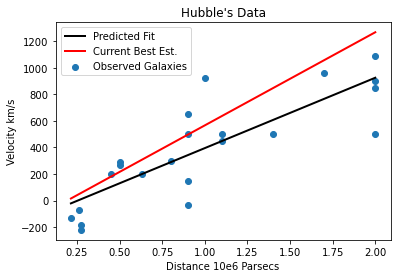

In [39]:
# Comp. Phys. : HW2.Q2 and Hw.Q3 -- Examine and plot Hubble's original data; return a line of best fit; compare to Hubble's constant

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

N = 22
operator = 1/N


# distance x-axis
r = np.array([0.214, 0.263, 0.275, 0.275, 0.45, 0.5, 0.5, 
     0.63, 0.8, 0.9, 0.9, 0.9, 0.9, 1.0, 1.1, 1.1, 1.4,
     1.7, 2.0, 2.0, 2.0, 2.0])


# velocity y-axis
v =  np.array([-130, -70, -185, -220, 200, 290, 270, 200,
     300, -30, 650, 150, 500, 920, 450, 500, 500, 960, 500,
     850, 900, 1090])

# quantities needed to find slope and intercept
Ex = (1/N) * sum(r)
Ey = (1/N) * sum(v)
Exx = (1/N) * sum(r**2)
Exy = sum([a*b for a, b in zip(r, v)]) * operator

# slope
m = [Exy - (Ex * Ey)] / (Exx - Ex**2)

# intercept
c = [(Exx * Ey) - (Ex * Exy)] / (Exx - Ex**2)

print(m, c)

# set up the data
plt.title("Hubble's Data")
plt.xlabel("Distance 10e6 Parsecs")
plt.ylabel("Velocity km/s")
plt.scatter(r,v,label="Observed Galaxies")


# predicted y-values for best fit line
y_predict = (r * m) + c
y_current = (r * 700) + c


# plot the data w/ line
plt.plot(r, y_predict, 'k-', lw=2, label="Predicted Fit")
plt.plot(r, y_current, 'r', lw=2, label="Current Best Est.")


plt.legend()

# something doesn't seem right regarding the red line
# I must have done something wrong when attempting to run @ 70 km/s 
# I ran @ 70 km/s and the red line was essentially horizontal -- looks 'better' @ 700 but I feel that it is wrong

Slope:  [528.96682563]
Intercept:  [-133.64452575]
Trial One:
Error on a:  [24619.18181518]
Change in a:  [24620.91305098]
Error on b:  1.796073469650579e-14
Change in b:  [1.38725073e-14]
Chi Squared:  -721.5248061161349
Trial Two:
Error on a:  [98537.45681518]
Change in a:  [98539.18805098]
Error on b:  -1.4301238473202692e-14
Change in b:  [-1.83894658e-14]
Chi Squared:  -736.3249296901538


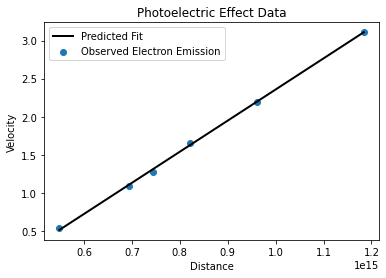

In [42]:
# Comp. Phys. HW2:Q4 (3.8 in textbook) -- Photoelectric Effect

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

N = 6
operator = 1/N

x = np.array([5.4874e+14, 6.931e+14, 7.4307e+14, 8.2193e+14, 9.6074e+14, 1.184e+15])
y = np.array([0.5309, 1.0842, 1.2734, 1.6598, 2.19856, 3.10891])

# quantities needed to find slope and intercept
Ex = operator * np.sum(x)
Ey = operator * np.sum(y)
Exx = operator * np.sum(x**2)
Exy = np.sum([a*b for a, b in zip(x, y)]) * operator

# slope
b = [Exy - (Ex * Ey)] / (Exx - Ex**2)

# intercept
a = [(Exx * Ey) - (Ex * Exy)] / (Exx - Ex**2)

print("Slope: ", m)
print("Intercept: ", c)

# getting predicted y-values
y_predict = (x * b) + a

# setting up the plot
plt.title("Photoelectric Effect Data")
plt.xlabel("Distance")
plt.ylabel("Velocity")
plt.scatter(x,y,label="Observed Electron Emission")
plt.plot(x, y_predict, 'k-', label="Predicted Fit", lw=2 )
plt.legend()

# assuming constant fractional error of 2%
sigma = .02
S = 1 / sigma**2
t =  (1 / sigma) * (x[0] - Sx/S)
Sy = np.sum(y * S)
Sx = np.sum(x * S)
Stt = np.sum(t**2)
error_a = Sy - (Sx * b) / S
error_b = (1/Stt) * np.sum((t * y) / sigma)
chi2 = (1 / N - 2) * ((np.sum(y - a - (b * x)*sigma)**2))
print("Trial One:")
print("Error on a: ", error_a)
print("Change in a: ", error_a - a)
print("Error on b: ", error_b)
print("Change in b: ", error_b - b)

print("Chi Squared: ", chi2)


# error on h?

# assuming constant fractional error of 1%
sigma = .01
S = 1 / sigma**2
t =  (1 / sigma) * (x[0] - Sx/S)
Sy = np.sum(y * S)
Sx = np.sum(x * S)
Stt = np.sum(t**2)
error_a = Sy - (Sx * b) / S
error_b = (1/Stt) * np.sum((t * y) / sigma)
chi2 = (1 / N - 2) * ((np.sum(y - a - (b * x)*sigma)**2))
print("Trial Two:")
print("Error on a: ", error_a)
print("Change in a: ", error_a - a)
print("Error on b: ", error_b)
print("Change in b: ", error_b - b)
print("Chi Squared: ", chi2)

# error on h?  

#-----------------------------------

# Comments on Parameter Errors
# a goes way up as does its error
# b decreases -- goes negative -- error too
# chi2 increases negatively 
